# 🔬 CornOrb Keratoconus Detection
## Multi-Map Fusion: CNN (ResNet-50) vs Vision Transformer (ViT-B/16)

---

### 📌 Overview
This notebook implements a complete deep learning pipeline for **keratoconus detection** using the **CornOrb dataset**, which contains Orbscan 3 corneal topography images from 744 patients.

Instead of using a single map type, we exploit **all four corneal maps simultaneously**:
- **Axial Curvature** — measures the curvature of the anterior corneal surface
- **Anterior Elevation** — deviation of the anterior surface from a reference sphere
- **Posterior Elevation** — deviation of the posterior surface from a reference sphere
- **Pachymetry** — corneal thickness map

Each eye is represented as a **12-channel tensor** (4 maps × 3 RGB channels), which is fed into both models simultaneously, allowing them to learn complementary patterns across all maps.

### 🗺️ Input Fusion Strategy
```
Channels  0–2  →  Axial Curvature      (R, G, B)
Channels  3–5  →  Anterior Elevation   (R, G, B)
Channels  6–8  →  Posterior Elevation  (R, G, B)
Channels  9–11 →  Pachymetry           (R, G, B)
─────────────────────────────────────────────────
Total Input Shape: [Batch, 12, 224, 224]
```

### 📂 Expected Google Drive Structure
```
My Drive/
  └── ORBSCAN_Dataset/
        ├── ORBSCAN_Dataset/
        │     ├── 1AAX3/
        │     │     ├── OD/   ← Axial.png, Anterior.png, Posterior.png, Pachymetry.png
        │     │     └── OS/
        │     ├── 1B2TY/ ...
        ├── clinical_data_and_labels.csv
        └── CornOrb_Keratoconus....csv
```

### 🗂️ Notebook Sections
| # | Section | Description |
|---|---------|-------------|
| 1 | Mount & Install | Connect Google Drive, install libraries |
| 2 | Imports & Seed | All imports, reproducibility setup |
| 3 | Configuration | Paths, hyperparameters, constants |
| 4 | Explore Structure | Detect actual image filenames |
| 5 | Load CSV | Parse & normalize the annotation file |
| 6 | Validate Maps | Confirm all 4 maps exist per eye |
| 7 | EDA | Visualize dataset statistics |
| 8 | Data Split | Patient-level train/val/test split |
| 9 | Transforms | Augmentation pipeline for 4-map input |
| 10 | Dataset Class | PyTorch Dataset returning 12-ch tensors |
| 11 | CNN Model | ResNet-50 with modified 12-ch stem |
| 12 | ViT Model | ViT-B/16 with modified 12-ch patch embed |
| 13 | Training Loop | Shared training utilities |
| 14 | Train CNN | Full CNN training run |
| 15 | Train ViT | Full ViT training run |
| 16 | Save to Drive | Copy weights to Google Drive |
| 17 | Training Curves | Loss & accuracy plots |
| 18 | Test Evaluation | Classification report on held-out test set |
| 19 | Confusion Matrices | Per-class breakdown with counts & percentages |
| 20 | ROC Curves | AUC comparison between models |
| 21 | Final Comparison | Bar chart + Radar chart + summary table |

---
## Section 1 — Mount Google Drive & Install Dependencies

**Why this step?**  
Google Colab runs on a temporary virtual machine that resets after each session. We need to:
1. Mount Google Drive so we can access our dataset files.
2. Install `timm` (PyTorch Image Models), which provides the pretrained ViT-B/16 architecture.

> ⚠️ A browser popup will appear asking for permission to access Drive — click **Allow**.

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
print('✅ Google Drive mounted at /content/drive')

Mounted at /content/drive
✅ Google Drive mounted at /content/drive


In [29]:
# timm (Timm Image Models) is a library by Ross Wightman containing
# hundreds of pretrained vision models including ViT variants.
# -q flag suppresses verbose install output.
!pip install timm -q
print('✅ timm installed successfully')

✅ timm installed successfully


---
## Section 2 — Imports & Reproducibility

**Why this step?**  
We import all required libraries upfront and configure a global random seed.

**Reproducibility** is critical in ML research: by fixing seeds for Python's `random`, NumPy, and PyTorch (including CUDA), we ensure that:
- Weight initialization is identical across runs.
- Data shuffling order is consistent.
- Results are fully reproducible and comparable.

**Key libraries:**
- `torch` / `torchvision` — deep learning framework and pretrained CNN models
- `timm` — provides ViT-B/16 pretrained weights
- `sklearn` — evaluation metrics (accuracy, F1, AUC, confusion matrix)
- `PIL` — image loading
- `matplotlib` / `seaborn` — all visualizations

In [3]:
import os, random, shutil, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm.notebook import tqdm
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import timm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    accuracy_score, f1_score, precision_score, recall_score
)

# ── Global Random Seed ────────────────────────────────────────────────────────
# We fix the seed for every random number generator involved in training.
# SEED = 42 is a common convention; any fixed integer works.
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)                      # Python built-in random
    np.random.seed(seed)                   # NumPy random
    torch.manual_seed(seed)                # PyTorch CPU
    torch.cuda.manual_seed_all(seed)       # PyTorch GPU (all devices)
    torch.backends.cudnn.deterministic = True  # Deterministic convolutions
    torch.backends.cudnn.benchmark = False     # Disable auto-tuning

set_seed()

# ── Device Selection ─────────────────────────────────────────────────────────
# Automatically use GPU (CUDA) if available, otherwise fall back to CPU.
# In Colab: Runtime > Change runtime type > T4 GPU to enable CUDA.
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'✅ Device  : {DEVICE}')
print(f'✅ PyTorch : {torch.__version__}')
print(f'✅ timm    : {timm.__version__}')
if DEVICE.type == 'cuda':
    print(f'✅ GPU     : {torch.cuda.get_device_name(0)}')
    print(f'   VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

✅ Device  : cuda
✅ PyTorch : 2.10.0+cu128
✅ timm    : 1.0.26
✅ GPU     : Tesla T4
   VRAM   : 15.6 GB


---
## Section 3 — Configuration

**Why this step?**  
Centralizing all hyperparameters and paths in one place makes the notebook easy to maintain. Instead of hunting through multiple cells to change a learning rate or batch size, everything is edited here.

**Key decisions explained:**
- `IMG_SIZE = 224` — standard input size for ImageNet pretrained models (both ResNet and ViT)
- `BATCH_SIZE = 16` — smaller than usual because our input has **12 channels** instead of 3, consuming ~4× more GPU memory
- `IN_CHANNELS = 12` — 4 maps × 3 RGB channels; this is the key parameter that distinguishes this notebook from single-map approaches
- `LR = 5e-5` — conservative learning rate for fine-tuning pretrained models
- `NUM_EPOCHS = 40` — maximum epochs; early stopping will trigger before this if validation accuracy plateaus

In [4]:
# ════════════════════════════════════════════════════════════════════════════
#  ✏️  EDIT THESE PATHS IF YOUR DRIVE STRUCTURE IS DIFFERENT
# ════════════════════════════════════════════════════════════════════════════

# Root folder inside Google Drive that contains the dataset
DRIVE_ROOT  = Path('/content/drive/MyDrive/ORBSCAN_Dataset')

# Sub-folder that contains patient folders (1AAX3, 1B2TY, ...)
IMAGES_ROOT = DRIVE_ROOT / 'ORBSCAN_Dataset'

# Try multiple common CSV names; the first one found is used
CSV_CANDIDATES = [
    DRIVE_ROOT / 'clinical_data_and_labels.csv',
    DRIVE_ROOT / 'CornOrb_Keratoconus_labels.csv',
    DRIVE_ROOT / 'clinical_annotations.csv',
]

CSV_PATH = next((p for p in CSV_CANDIDATES if p.exists()), None)
if CSV_PATH is None:
    print('⚠️  No CSV found. Files present in DRIVE_ROOT:')
    for f in DRIVE_ROOT.iterdir():
        print(f'   {f.name}')
    raise FileNotFoundError('Please update CSV_CANDIDATES with the correct filename.')
print(f'✅ CSV found: {CSV_PATH.name}')

# ── Map Configuration ─────────────────────────────────────────────────────────
# The four Orbscan 3 maps we use — order matters! It defines channel order.
ALL_MAPS    = ['Axial', 'Anterior', 'Posterior', 'Pachymetry']
IN_CHANNELS = len(ALL_MAPS) * 3   # 4 maps × RGB = 12 channels

# ── Training Hyperparameters ──────────────────────────────────────────────────
IMG_SIZE     = 224    # Input spatial resolution (standard for ViT and ResNet)
BATCH_SIZE   = 16     # Reduced vs. 3-ch baseline because 12-ch uses ~4× GPU memory
NUM_EPOCHS   = 40     # Maximum training epochs (early stopping may trigger earlier)
LR           = 5e-5   # Learning rate for AdamW optimizer
WEIGHT_DECAY = 1e-4   # L2 regularization strength

# ── Train / Validation / Test Proportions ────────────────────────────────────
TRAIN_RATIO = 0.70    # 70% of patients for training
VAL_RATIO   = 0.15    # 15% for validation (hyperparameter tuning & early stopping)
TEST_RATIO  = 0.15    # 15% for final evaluation (never seen during training)

# ── Output Directory ──────────────────────────────────────────────────────────
# Model weights are saved here during training (inside Colab runtime).
# At the end, they are copied to Google Drive for persistent storage.
WEIGHTS_DIR = Path('/content/weights')
WEIGHTS_DIR.mkdir(exist_ok=True)

print(f'\n📊 Input channels : {IN_CHANNELS}  (4 maps × 3 RGB)')
print(f'📐 Image size      : {IMG_SIZE}×{IMG_SIZE} pixels')
print(f'📦 Batch size      : {BATCH_SIZE}')
print(f'🔁 Max epochs      : {NUM_EPOCHS}')
print(f'📁 Images root     : {IMAGES_ROOT}')
print(f'💾 Weights dir     : {WEIGHTS_DIR}')

✅ CSV found: clinical_data_and_labels.csv

📊 Input channels : 12  (4 maps × 3 RGB)
📐 Image size      : 224×224 pixels
📦 Batch size      : 16
🔁 Max epochs      : 40
📁 Images root     : /content/drive/MyDrive/ORBSCAN_Dataset/ORBSCAN_Dataset
💾 Weights dir     : /content/weights


---
## Section 4 — Explore Drive Structure & Auto-Detect Image Filenames

**Why this step?**  
The exact filenames of the corneal maps may vary between exports (e.g., `Axial.png`, `axial_curvature.png`, `OD_Axial.png`, etc.). Rather than hardcoding a fixed name, we use a **keyword-based detection function** that searches each eye folder for images whose filenames contain expected keywords.

This makes the code robust to naming variations across different Orbscan export settings.

**How it works:**
1. `MAP_KEYWORDS` maps each map type to a list of possible substrings.
2. `find_map_file()` scans the folder and returns the first image file whose name contains any of those substrings (case-insensitive).
3. We test on one sample patient to verify detection before processing the full dataset.

> ⚠️ **If any map shows `NOT FOUND`**, open `MAP_KEYWORDS` and add the actual keyword from the filenames printed above.

In [5]:
# ── Keyword-to-MapType Mapping ────────────────────────────────────────────────
# Each key is a map type; its value is a list of substrings we search for
# in image filenames (lowercase, case-insensitive comparison).
MAP_KEYWORDS = {
    'Axial'     : ['axial', 'axial_curvature', 'axialcurvature', 'curvature'],
    'Anterior'  : ['anterior', 'ant_elev', 'anterior_elevation', 'ant'],
    'Posterior' : ['posterior', 'post_elev', 'posterior_elevation', 'post'],
    'Pachymetry': ['pachy', 'pachymetry', 'thickness'],
}

def find_map_file(eye_dir: Path, map_type: str):
    """
    Search an eye folder for an image file matching the given map type.

    Parameters
    ----------
    eye_dir   : Path — path to the OD or OS sub-folder
    map_type  : str  — one of 'Axial', 'Anterior', 'Posterior', 'Pachymetry'

    Returns
    -------
    Path if found, None otherwise.
    """
    keywords = MAP_KEYWORDS.get(map_type, [map_type.lower()])
    for f in sorted(eye_dir.iterdir()):
        if f.suffix.lower() in ('.png', '.jpg', '.jpeg', '.bmp', '.tiff'):
            if any(kw in f.stem.lower() for kw in keywords):
                return f
    return None

def get_eye_dir(row) -> Path:
    """Return the OD or OS sub-folder Path for a given DataFrame row."""
    return IMAGES_ROOT / str(row['patient_code']) / str(row['eye'])

# ── Test on the first patient folder ─────────────────────────────────────────
sample_patient = next(p for p in sorted(IMAGES_ROOT.iterdir()) if p.is_dir())
sample_eye_dir = next(p for p in sorted(sample_patient.iterdir()) if p.is_dir())

print(f'Sample patient  : {sample_patient.name}')
print(f'Sample eye dir  : {sample_eye_dir.name}')
print(f'Files inside    : {[f.name for f in sorted(sample_eye_dir.iterdir())]}')
print()
print('Map detection results:')
for mt in ALL_MAPS:
    hit = find_map_file(sample_eye_dir, mt)
    status = f'✅  {hit.name}' if hit else '❌  NOT FOUND — update MAP_KEYWORDS'
    print(f'  {mt:14s} → {status}')

Sample patient  : 125GC
Sample eye dir  : OD
Files inside    : ['125GC_OD_Anterior.png', '125GC_OD_Axial.png', '125GC_OD_Pachymetry.png', '125GC_OD_Posterior.png']

Map detection results:
  Axial          → ✅  125GC_OD_Axial.png
  Anterior       → ✅  125GC_OD_Anterior.png
  Posterior      → ✅  125GC_OD_Posterior.png
  Pachymetry     → ✅  125GC_OD_Pachymetry.png


---
## Section 5 — Load CSV & Normalize Column Names

**Why this step?**  
The CSV file contains demographic and clinical annotations for each eye, including the diagnostic label (`0 = Normal`, `1 = Keratoconus`). However, column names may differ between CSV versions (e.g., `PatientID` vs `patient_code`, `Diagnosis` vs `label`). We normalize all column names to a consistent schema to make downstream code reliable.

**Key columns we need:**
- `patient_code` — unique patient identifier (used for patient-level splitting)
- `eye` — laterality: `OD` (right) or `OS` (left)
- `label` — binary class: `0 = Normal`, `1 = Keratoconus`
- `age`, `sex` — optional demographics used in EDA

In [6]:
# Load the raw CSV
df_raw = pd.read_csv(CSV_PATH)
print(f'Raw CSV shape : {df_raw.shape}')
print(f'Columns       : {list(df_raw.columns)}')
df_raw.head(3)

Raw CSV shape : (1454, 15)
Columns       : ['patient_code', 'eye', 'age_years', 'gender', 'astig_value_D', 'astig_axis_deg', 'kmax_value_D', 'kmax_axis_deg', 'pachy_central_um', 'pachy_thinnest_um', 'pachy_thinnest_x', 'pachy_thinnest_y', 'asphericity_anterior', 'asphericity_posterior', 'label']


,patient_code,eye,age_years,gender,astig_value_D,astig_axis_deg,kmax_value_D,kmax_axis_deg,pachy_central_um,pachy_thinnest_um,pachy_thinnest_x,pachy_thinnest_y,asphericity_anterior,asphericity_posterior,label
0,63358,OS,41,m,-2.2,156,45.5,66,530,514,1.1,-0.9,-0.19,0.08,0
1,UAXDY,OS,30,f,-1.5,6,44.0,96,517,514,0.0,0.5,-0.29,-0.29,0
2,MF9GX,OD,23,m,-2.2,10,43.2,100,528,525,1.5,0.0,-0.25,2.21,0


In [7]:
# ── Column Name Normalization ─────────────────────────────────────────────────
# We build a renaming dictionary by matching each column's lowercase version
# against known aliases for each required field.
col_map = {}
for col in df_raw.columns:
    cl = col.lower().replace(' ', '_')
    # Patient identifier
    if cl in ('patient_code', 'patientid', 'patient_id', 'id', 'code'):
        col_map[col] = 'patient_code'
    # Eye laterality
    elif cl in ('eye', 'laterality', 'eye_laterality', 'side'):
        col_map[col] = 'eye'
    # Diagnostic label
    elif cl in ('label', 'diagnosis', 'class', 'keratoconus', 'target'):
        col_map[col] = 'label'
    # Optional demographics
    elif cl == 'age':
        col_map[col] = 'age'
    elif cl in ('sex', 'gender'):
        col_map[col] = 'sex'

df = df_raw.rename(columns=col_map).copy()

# ── Type Casting & Cleaning ───────────────────────────────────────────────────
df['patient_code'] = df['patient_code'].astype(str).str.strip()
df['eye']          = df['eye'].astype(str).str.strip().str.upper()  # Ensure OD/OS uppercase
df['label']        = df['label'].astype(int)                        # Ensure 0/1 integers

print(f'Renamed columns : {list(df.columns)}')
print(f'Total rows      : {len(df)}')
print(f'\nClass distribution:')
print(df['label'].value_counts().rename({0: 'Normal', 1: 'Keratoconus'}))
print(f'\nEye distribution:')
print(df['eye'].value_counts())

Renamed columns : ['patient_code', 'eye', 'age_years', 'sex', 'astig_value_D', 'astig_axis_deg', 'kmax_value_D', 'kmax_axis_deg', 'pachy_central_um', 'pachy_thinnest_um', 'pachy_thinnest_x', 'pachy_thinnest_y', 'asphericity_anterior', 'asphericity_posterior', 'label']
Total rows      : 1454

Class distribution:
label
Normal         889
Keratoconus    565
Name: count, dtype: int64

Eye distribution:
eye
OD    730
OS    724
Name: count, dtype: int64


---
## Section 6 — Validate That All 4 Maps Exist Per Eye

**Why this step?**  
Because our model requires all 4 maps simultaneously, any eye that is missing even one map cannot be used. This cell checks every eye in the dataset and filters out incomplete records. This ensures we never encounter a `FileNotFoundError` during training.

> This check may take a minute depending on the number of eyes and Drive latency.

In [8]:
def all_maps_exist(row) -> bool:
    """
    Returns True only if the patient folder exists AND
    all four map images are detected inside the eye sub-folder.
    """
    eye_dir = get_eye_dir(row)
    if not eye_dir.exists():
        return False
    return all(find_map_file(eye_dir, mt) is not None for mt in ALL_MAPS)

print('Validating all 4 maps for each eye... (this may take ~1 minute)')
df['all_maps_ok'] = df.apply(all_maps_exist, axis=1)

n_ok      = df['all_maps_ok'].sum()
n_missing = (~df['all_maps_ok']).sum()
print(f'\nEyes with all 4 maps present : {n_ok}')
print(f'Eyes with missing maps       : {n_missing}')

if n_missing > 0:
    print('\nSample of incomplete eyes (excluded from dataset):')
    print(df[~df['all_maps_ok']][['patient_code', 'eye', 'label']].head(10))

# Keep only eyes with all 4 maps
df = df[df['all_maps_ok']].reset_index(drop=True)

print(f'\nFinal usable dataset: {len(df)} eyes')
print(df['label'].value_counts().rename({0: 'Normal', 1: 'Keratoconus'}))

Validating all 4 maps for each eye... (this may take ~1 minute)

Eyes with all 4 maps present : 1452
Eyes with missing maps       : 2

Sample of incomplete eyes (excluded from dataset):
    patient_code eye  label
240       3E+132  OS      0
330       3E+132  OD      0

Final usable dataset: 1452 eyes
label
Normal         887
Keratoconus    565
Name: count, dtype: int64


---
## Section 7 — Exploratory Data Analysis (EDA)

**Why this step?**  
Before training, we visualize the dataset to understand:
1. **Class imbalance** — are Normal and Keratoconus cases balanced? Imbalance affects model training and metric interpretation.
2. **Age distribution** — the paper reports that Keratoconus patients are significantly younger (27.9 vs 33.5 years), which aligns with the disease's natural progression.
3. **Eye laterality** — do OD (right) and OS (left) follow similar class distributions?
4. **Visual inspection** — viewing all 4 maps side-by-side reveals how each map captures different aspects of corneal pathology.

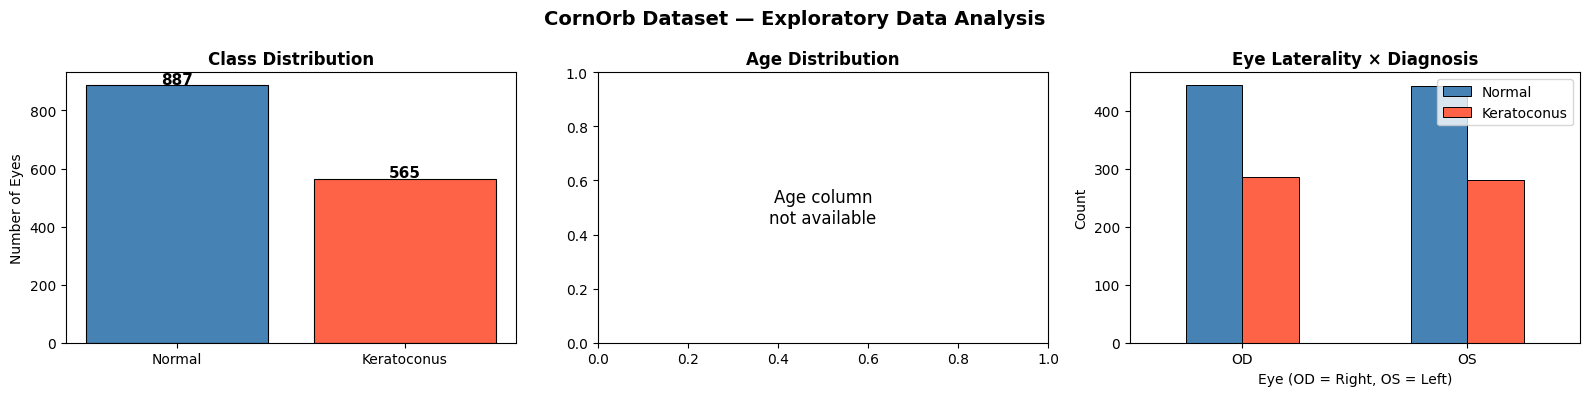

In [9]:
# ── Statistical Overview Charts ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('CornOrb Dataset — Exploratory Data Analysis', fontsize=14, fontweight='bold')

# Plot 1: Class Distribution
# Shows the number of Normal vs Keratoconus eyes.
# A large imbalance requires countermeasures (weighted sampler, class weights).
counts = df['label'].value_counts()
bars = axes[0].bar(
    ['Normal', 'Keratoconus'], counts.values,
    color=['steelblue', 'tomato'], edgecolor='black', linewidth=0.8
)
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Number of Eyes')
for bar, val in zip(bars, counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2, val + 5,
        str(val), ha='center', fontweight='bold', fontsize=11
    )

# Plot 2: Age Distribution by Diagnosis
# Keratoconus typically affects younger patients.
# Age is a useful auxiliary feature and a useful sanity check.
if 'age' in df.columns:
    for lbl, color, name in [(0, 'steelblue', 'Normal'), (1, 'tomato', 'Keratoconus')]:
        axes[1].hist(
            df[df['label'] == lbl]['age'], bins=20, alpha=0.65,
            color=color, label=name, edgecolor='black', linewidth=0.4
        )
    axes[1].set_title('Age Distribution by Diagnosis', fontweight='bold')
    axes[1].set_xlabel('Age (years)')
    axes[1].set_ylabel('Count')
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, 'Age column\nnot available',
                 ha='center', va='center', transform=axes[1].transAxes, fontsize=12)
    axes[1].set_title('Age Distribution', fontweight='bold')

# Plot 3: Eye Laterality (OD vs OS) broken down by class
# Confirms that both eyes are similarly represented across classes.
lat_counts = df.groupby(['eye', 'label']).size().unstack(fill_value=0)
lat_counts.columns = ['Normal', 'Keratoconus']
lat_counts.plot(
    kind='bar', ax=axes[2],
    color=['steelblue', 'tomato'], edgecolor='black', linewidth=0.7
)
axes[2].set_title('Eye Laterality × Diagnosis', fontweight='bold')
axes[2].set_xlabel('Eye (OD = Right, OS = Left)')
axes[2].set_ylabel('Count')
axes[2].set_xticklabels(lat_counts.index, rotation=0)

plt.tight_layout()
plt.savefig('/content/dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()

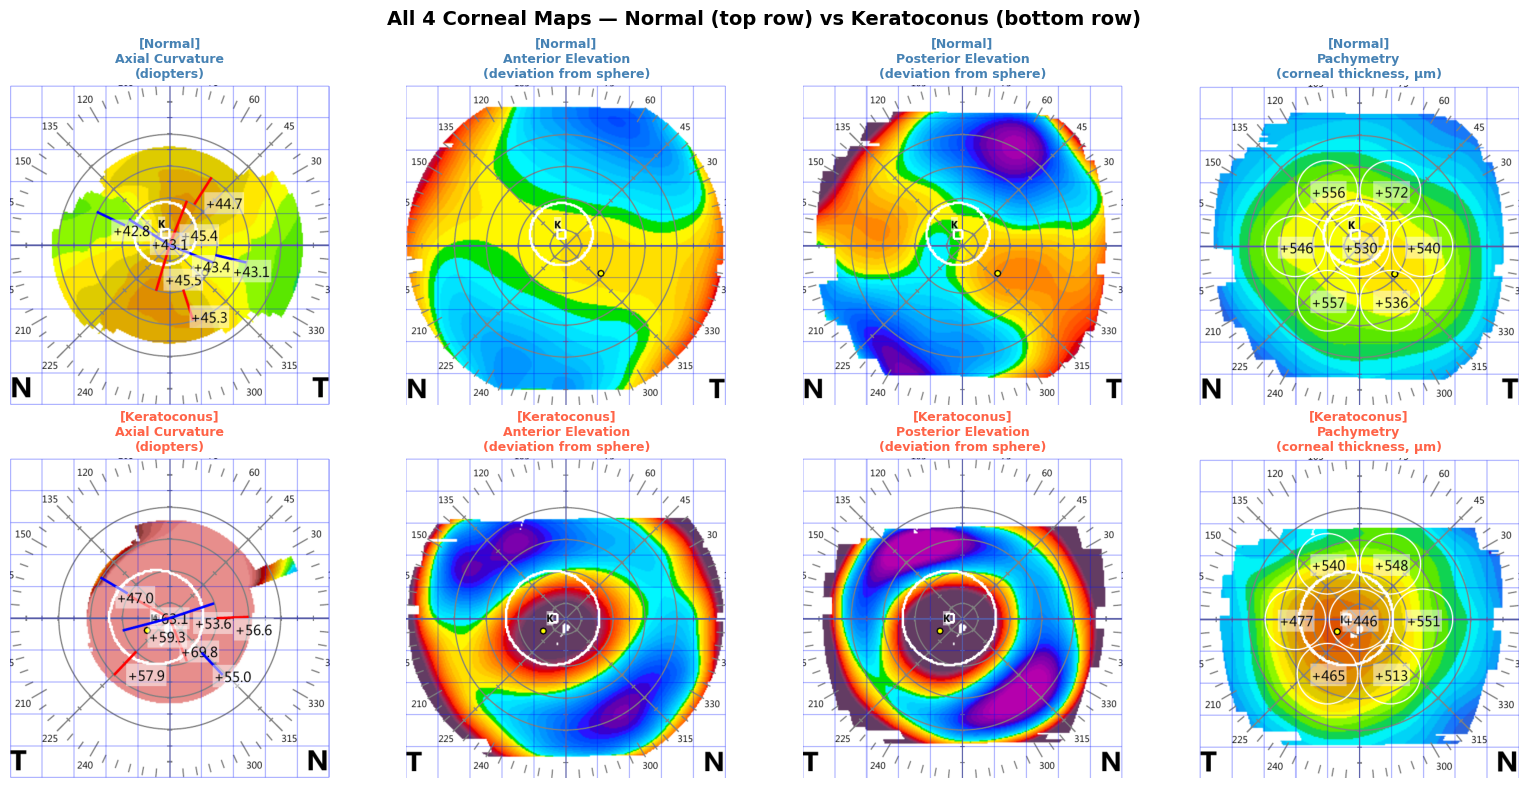

In [10]:
# ── Visual Inspection: All 4 Maps for 1 Normal + 1 Keratoconus Eye ────────────
# This is the most important EDA step for corneal topography:
# - Normal eyes show smooth, symmetric patterns.
# - Keratoconus eyes show asymmetric steepening, thinning, and elevation.
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle(
    'All 4 Corneal Maps — Normal (top row) vs Keratoconus (bottom row)',
    fontsize=14, fontweight='bold'
)

map_descriptions = {
    'Axial'     : 'Axial Curvature\n(diopters)',
    'Anterior'  : 'Anterior Elevation\n(deviation from sphere)',
    'Posterior' : 'Posterior Elevation\n(deviation from sphere)',
    'Pachymetry': 'Pachymetry\n(corneal thickness, µm)',
}

for row_idx, (cls, cls_name) in enumerate([(0, 'Normal'), (1, 'Keratoconus')]):
    sample_row = df[df['label'] == cls].iloc[0]
    eye_dir    = get_eye_dir(sample_row)
    for col_idx, mt in enumerate(ALL_MAPS):
        img_path = find_map_file(eye_dir, mt)
        img = Image.open(img_path).convert('RGB')
        axes[row_idx, col_idx].imshow(img)
        title = (
            f'[{cls_name}]\n'
            f'{map_descriptions[mt]}'
        )
        color = 'steelblue' if cls == 0 else 'tomato'
        axes[row_idx, col_idx].set_title(title, fontsize=9, color=color, fontweight='bold')
        axes[row_idx, col_idx].axis('off')

plt.tight_layout()
plt.savefig('/content/all_maps_sample.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 8 — Patient-Level Train / Validation / Test Split

**Why this step?**  
Data splitting must be done at the **patient level**, not the eye level. If we split by eye, the model could potentially see the OD (right eye) of a patient in training and the OS (left eye) in validation — leading to **data leakage**, since the two eyes of the same patient are highly correlated.

By splitting at the patient level:
- All eyes of a given patient stay in the same subset.
- The test set contains eyes from patients the model has **never encountered** in any form.

**Stratification** ensures the same class ratio (Normal:Keratoconus) is preserved in all three subsets, preventing accidental imbalance in the test set.

**Split ratios:** 70% train / 15% validation / 15% test

In [11]:
# ── Step 1: Compute a majority label per patient ──────────────────────────────
# A patient with both OD=Normal and OS=Normal gets label=0.
# A patient with OD=KC and OS=KC gets label=1.
# A patient with mixed labels gets whichever appears more (mode).
# This label is only used for stratification — it does NOT override individual eye labels.
patient_label = (
    df.groupby('patient_code')['label']
      .agg(lambda x: int(x.mode()[0]))
      .reset_index()
)

# ── Step 2: First split — separate Training from (Validation + Test) ──────────
train_patients, temp_patients = train_test_split(
    patient_label,
    test_size=(1 - TRAIN_RATIO),
    stratify=patient_label['label'],
    random_state=SEED
)

# ── Step 3: Second split — separate Validation from Test ─────────────────────
# The ratio here is relative to the remaining (val + test) pool.
val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=TEST_RATIO / (VAL_RATIO + TEST_RATIO),
    stratify=temp_patients['label'],
    random_state=SEED
)

# ── Step 4: Filter the eye-level DataFrame by patient membership ──────────────
train_df = df[df['patient_code'].isin(train_patients['patient_code'])].reset_index(drop=True)
val_df   = df[df['patient_code'].isin(val_patients['patient_code'])].reset_index(drop=True)
test_df  = df[df['patient_code'].isin(test_patients['patient_code'])].reset_index(drop=True)

print('Data split summary:')
print(f'  Train : {len(train_df):4d} eyes  |  KC: {train_df["label"].sum():4d}  |  '
      f'KC ratio: {train_df["label"].mean()*100:.1f}%')
print(f'  Val   : {len(val_df):4d} eyes  |  KC: {val_df["label"].sum():4d}  |  '
      f'KC ratio: {val_df["label"].mean()*100:.1f}%')
print(f'  Test  : {len(test_df):4d} eyes  |  KC: {test_df["label"].sum():4d}  |  '
      f'KC ratio: {test_df["label"].mean()*100:.1f}%')
print(f'\nTotal patients: {len(patient_label)}')
print(f'  Train patients: {len(train_patients)}')
print(f'  Val patients  : {len(val_patients)}')
print(f'  Test patients : {len(test_patients)}')

Data split summary:
  Train : 1019 eyes  |  KC:  399  |  KC ratio: 39.2%
  Val   :  215 eyes  |  KC:   83  |  KC ratio: 38.6%
  Test  :  218 eyes  |  KC:   83  |  KC ratio: 38.1%

Total patients: 743
  Train patients: 520
  Val patients  : 111
  Test patients : 112


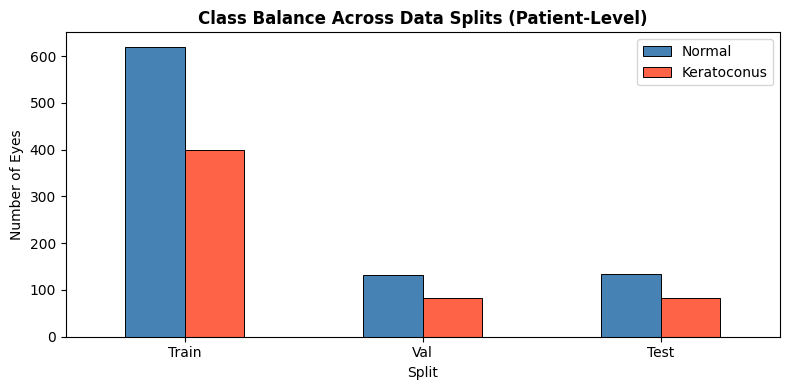

In [12]:
# ── Visualize the split class balance ─────────────────────────────────────────
# This confirms stratification worked correctly: all three subsets
# have approximately the same Normal:Keratoconus ratio.
split_info = pd.DataFrame({
    'Split'       : ['Train', 'Val', 'Test'],
    'Normal'      : [(d['label'] == 0).sum() for d in [train_df, val_df, test_df]],
    'Keratoconus' : [d['label'].sum()         for d in [train_df, val_df, test_df]]
}).set_index('Split')

split_info.plot(
    kind='bar', figsize=(8, 4),
    color=['steelblue', 'tomato'], edgecolor='black', linewidth=0.7
)
plt.title('Class Balance Across Data Splits (Patient-Level)', fontweight='bold')
plt.ylabel('Number of Eyes')
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('/content/data_split.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 9 — Data Augmentation & Transforms

**Why this step?**  
Data augmentation artificially increases dataset diversity by applying random but realistic transformations to training images. This reduces overfitting and improves the model's ability to generalize.

**Critical design decision for multi-map input:**  
All 4 maps of the same eye represent the *same physical cornea*, so spatial transformations (rotation, flip, crop) must be applied **identically** across all 4 maps. If we rotate the Axial map by 12° but the Pachymetry map by a different random angle, we corrupt the spatial correspondence between maps. We solve this by applying the same random seed before each spatial transform.

**Augmentation pipeline (training only):**
- **RandomCrop** — simulates slight misalignment
- **RandomHorizontalFlip / RandomVerticalFlip** — corneal patterns can appear in different orientations
- **RandomRotation ±15°** — corneal topography is roughly rotationally symmetric; small rotations are clinically realistic
- **RandomAffine** — slight translation and scaling
- **ColorJitter** — simulates imaging variability (brightness, contrast)
- **GaussianBlur** — simulates slight defocus
- **RandomErasing (Cutout)** — randomly masks small patches, forcing the model to learn globally robust features

**Normalization:**  
We use ImageNet mean and std repeated 4× for the 12 channels, since our models are initialized from ImageNet pretrained weights and this is the expected input distribution.

In [13]:
# ── Per-channel normalization statistics ──────────────────────────────────────
# ImageNet statistics (mean, std per channel) are used because our models
# start from ImageNet pretrained weights. We replicate these for all 4 maps.
IMAGENET_MEAN = [0.485, 0.456, 0.406]        # Standard ImageNet RGB mean
IMAGENET_STD  = [0.229, 0.224, 0.225]        # Standard ImageNet RGB std

MULTI_MEAN = IMAGENET_MEAN * 4  # 12-channel mean: [R,G,B, R,G,B, R,G,B, R,G,B]
MULTI_STD  = IMAGENET_STD  * 4  # 12-channel std

# ── Spatial Transforms ────────────────────────────────────────────────────────
# Applied IDENTICALLY to all 4 maps via shared random seed (see Dataset class)
spatial_train = transforms.Compose([
    transforms.Resize((IMG_SIZE + 20, IMG_SIZE + 20)),  # Slightly larger for random crop
    transforms.RandomCrop(IMG_SIZE),                    # Crop back to target size
    transforms.RandomHorizontalFlip(p=0.5),             # 50% chance of horizontal flip
    transforms.RandomVerticalFlip(p=0.3),               # 30% chance of vertical flip
    transforms.RandomRotation(degrees=15),              # Rotate by up to ±15 degrees
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),  # Up to 5% translation
        scale=(0.95, 1.05),      # Up to 5% zoom in/out
        shear=5                  # Up to 5° shear
    ),
])

spatial_eval = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),  # Just resize; no random ops
])

# ── Color/Intensity Transforms ────────────────────────────────────────────────
# Applied INDEPENDENTLY per map (each map has different color characteristics)
color_aug = transforms.Compose([
    transforms.ColorJitter(
        brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05
    ),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
])

# ── Utility Transforms ────────────────────────────────────────────────────────
to_tensor  = transforms.ToTensor()                     # PIL Image → [0,1] tensor
norm_multi = transforms.Normalize(MULTI_MEAN, MULTI_STD)  # 12-channel normalization
cutout     = transforms.RandomErasing(p=0.2, scale=(0.02, 0.08))  # Cutout augmentation

print('Transforms defined:')
print(f'  Input tensor shape : [B, {IN_CHANNELS}, {IMG_SIZE}, {IMG_SIZE}]')
print(f'  Normalization      : 12-channel (ImageNet stats × 4)')
print(f'  Training augs      : Crop, Flip, Rotate, Affine, ColorJitter, Blur, Cutout')
print(f'  Eval pipeline      : Resize only + Normalize')

Transforms defined:
  Input tensor shape : [B, 12, 224, 224]
  Normalization      : 12-channel (ImageNet stats × 4)
  Training augs      : Crop, Flip, Rotate, Affine, ColorJitter, Blur, Cutout
  Eval pipeline      : Resize only + Normalize


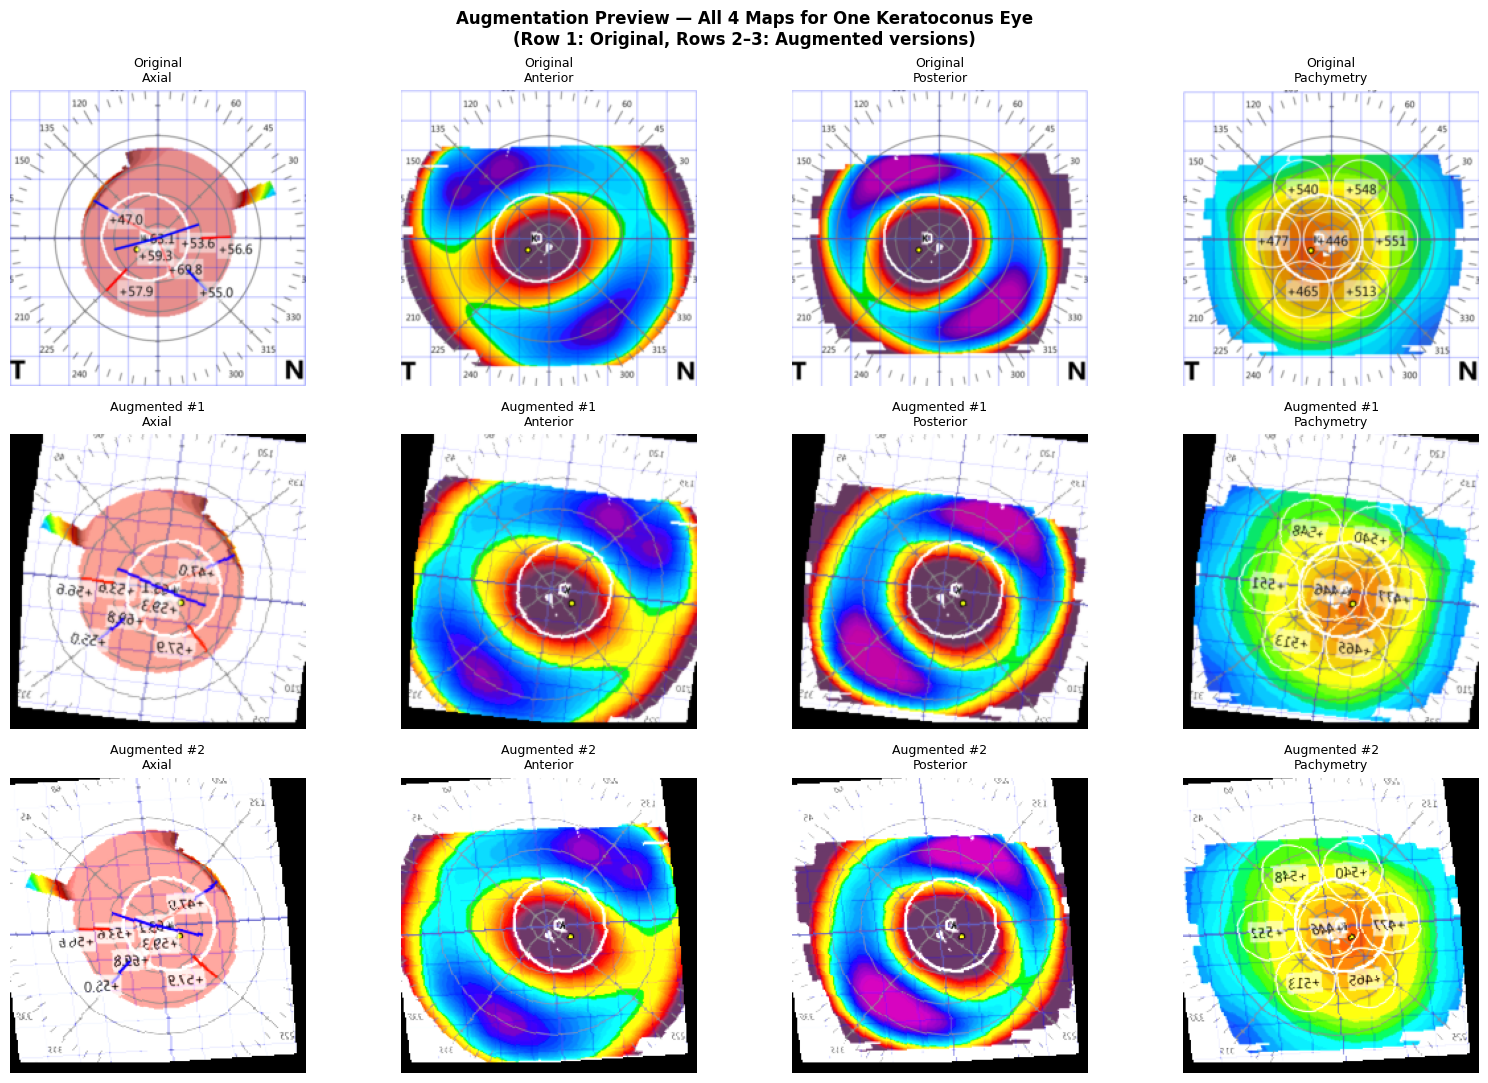

In [14]:
# ── Augmentation Visualization ────────────────────────────────────────────────
# Shows all 4 maps for one eye: original + 2 augmented versions.
# Confirms that spatial transforms are consistent across maps.
sample_row = df[df['label'] == 1].iloc[0]  # Pick a Keratoconus eye
eye_dir    = get_eye_dir(sample_row)

fig, axes = plt.subplots(3, 4, figsize=(16, 11))
fig.suptitle(
    'Augmentation Preview — All 4 Maps for One Keratoconus Eye\n'
    '(Row 1: Original, Rows 2–3: Augmented versions)',
    fontsize=12, fontweight='bold'
)
row_labels = ['Original', 'Augmented #1', 'Augmented #2']

for row_i in range(3):
    for col_i, mt in enumerate(ALL_MAPS):
        img = Image.open(find_map_file(eye_dir, mt)).convert('RGB')
        if row_i == 0:
            # Original: just resize
            t = to_tensor(transforms.Resize((IMG_SIZE, IMG_SIZE))(img))
        else:
            # Apply same spatial seed for all maps in this row
            seed = 100 + row_i
            torch.manual_seed(seed)
            random.seed(seed)
            img2 = spatial_train(img)
            img2 = color_aug(img2)
            t = to_tensor(img2)
        vis = t.permute(1, 2, 0).clamp(0, 1).numpy()
        axes[row_i, col_i].imshow(vis)
        axes[row_i, col_i].set_title(f'{row_labels[row_i]}\n{mt}', fontsize=9)
        axes[row_i, col_i].axis('off')

plt.tight_layout()
plt.savefig('/content/augmentation_demo.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 10 — PyTorch Dataset Class

**Why this step?**  
PyTorch requires a `Dataset` class that defines how to load individual samples. Our custom `CornOrbMultiMapDataset` class:
1. Loads all 4 map images for each eye.
2. Applies the same spatial transform to all 4 maps using a shared random seed (spatial consistency).
3. Applies independent color augmentation per map (maps have different color palettes).
4. Concatenates the 4 tensors into a single 12-channel tensor `[12, 224, 224]`.
5. Normalizes the full 12-channel tensor.

**Weighted Sampler:**  
Because the dataset is imbalanced (more Normal than Keratoconus eyes), we use a `WeightedRandomSampler` that **oversamples** Keratoconus cases during training. This ensures the model sees roughly equal numbers of both classes per batch, preventing it from simply predicting "Normal" for everything.

In [15]:
class CornOrbMultiMapDataset(Dataset):
    """
    Custom PyTorch Dataset for CornOrb multi-map classification.

    For each eye, loads all 4 corneal maps and concatenates them
    into a single 12-channel tensor [12, H, W].

    Spatial augmentation is applied with the same random seed
    across all 4 maps to preserve spatial correspondence.
    Color augmentation is applied independently per map.

    Parameters
    ----------
    dataframe : pd.DataFrame — rows are individual eyes with patient_code, eye, label
    is_train  : bool — if True, applies augmentation; if False, eval-only transforms
    """

    def __init__(self, dataframe: pd.DataFrame, is_train: bool = True):
        self.df       = dataframe.reset_index(drop=True)
        self.is_train = is_train

    def __len__(self) -> int:
        return len(self.df)

    def _load_map(self, eye_dir: Path, map_type: str) -> Image.Image:
        """Load one corneal map image as an RGB PIL Image."""
        path = find_map_file(eye_dir, map_type)
        if path is None:
            raise FileNotFoundError(
                f"Map '{map_type}' not found in {eye_dir}. "
                f"Check MAP_KEYWORDS in Section 4."
            )
        return Image.open(path).convert('RGB')

    def __getitem__(self, idx: int):
        row     = self.df.iloc[idx]
        label   = int(row['label'])
        eye_dir = get_eye_dir(row)

        # A single random seed for spatial transforms this sample.
        # All 4 maps share this seed → identical spatial augmentation.
        spatial_seed = random.randint(0, 2**32 - 1)

        tensors = []
        for mt in ALL_MAPS:
            img = self._load_map(eye_dir, mt)

            # 1. Apply identical spatial transform to all maps
            random.seed(spatial_seed)
            torch.manual_seed(spatial_seed)
            if self.is_train:
                img = spatial_train(img)   # Crop, Flip, Rotate, Affine
                img = color_aug(img)       # ColorJitter, Blur (independent per map)
            else:
                img = spatial_eval(img)    # Resize only

            # 2. Convert to tensor [3, H, W] with values in [0, 1]
            tensors.append(to_tensor(img))

        # 3. Concatenate along channel dimension: 4 × [3, H, W] → [12, H, W]
        multi_tensor = torch.cat(tensors, dim=0)

        # 4. Apply 12-channel normalization
        multi_tensor = norm_multi(multi_tensor)

        # 5. Cutout: randomly erase a small patch (training only)
        if self.is_train:
            multi_tensor = cutout(multi_tensor)

        return multi_tensor, label


# ── Build Dataset Objects ─────────────────────────────────────────────────────
train_dataset = CornOrbMultiMapDataset(train_df, is_train=True)
val_dataset   = CornOrbMultiMapDataset(val_df,   is_train=False)
test_dataset  = CornOrbMultiMapDataset(test_df,  is_train=False)

# ── Weighted Sampler for Class Imbalance ──────────────────────────────────────
# Assign a sampling weight inversely proportional to class frequency.
# Rare class (Keratoconus) gets higher weight → sampled more often.
labels_arr   = train_df['label'].values
class_counts = np.bincount(labels_arr)                    # [n_normal, n_kc]
sample_w     = (1.0 / class_counts)[labels_arr]           # Weight per sample
sampler      = torch.utils.data.WeightedRandomSampler(
    weights=sample_w,
    num_samples=len(sample_w),
    replacement=True
)

# ── DataLoaders ───────────────────────────────────────────────────────────────
# num_workers=2 uses 2 CPU threads for parallel data loading.
# pin_memory=True speeds up CPU→GPU transfers.
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    sampler=sampler, num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True
)

# ── Sanity Check ─────────────────────────────────────────────────────────────
sample_x, sample_y = next(iter(train_loader))
print(f'Batch tensor shape : {sample_x.shape}  ← [B, 12, 224, 224] ✅')
print(f'Batch labels shape : {sample_y.shape}')
print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')

Batch tensor shape : torch.Size([16, 12, 224, 224])  ← [B, 12, 224, 224] ✅
Batch labels shape : torch.Size([16])
Train batches : 64
Val batches   : 14
Test batches  : 14


---
## Section 11 — Model 1: Multi-Map CNN (ResNet-50)

**Why ResNet-50?**  
ResNet-50 is a well-established convolutional backbone with residual connections that help train deep networks. It achieves strong performance on medical imaging tasks and is computationally efficient.

**The core challenge: 12-channel input**  
Standard ResNet-50 expects 3-channel (RGB) input. Its first layer is `Conv2d(3, 64, kernel_size=7, stride=2)`. We replace this with `Conv2d(12, 64, ...)` to accept our 12-channel multi-map tensor.

**Weight initialization for the new stem:**  
Rather than training from random noise, we **inherit** the pretrained 3-channel weights by replicating them across the 4 input groups and dividing by 4. This ensures the model starts with meaningful feature detectors rather than random noise, significantly speeding up convergence.

**Freezing strategy:**  
- `layer1` and `layer2` — **frozen** (early feature detectors like edges/textures are already learned)
- `layer3`, `layer4`, classifier head — **trainable** (high-level semantic features adapt to corneal topography)

In [16]:
class MultiMapCNN(nn.Module):
    """
    ResNet-50 modified for 12-channel multi-map keratoconus classification.

    Architecture:
    ─────────────
    Input [B, 12, 224, 224]
        ↓ Modified Conv2d(12→64, 7×7, stride=2)   ← New stem
        ↓ BatchNorm, ReLU, MaxPool
        ↓ ResNet Layer1 (frozen)
        ↓ ResNet Layer2 (frozen)
        ↓ ResNet Layer3 (trainable)
        ↓ ResNet Layer4 (trainable)
        ↓ Global Average Pooling → [B, 2048]
        ↓ Linear(2048→512) + BN + ReLU + Dropout
        ↓ Linear(512→128)  + BN + ReLU + Dropout
        ↓ Linear(128→2)
    Output: logits [B, 2]
    """

    def __init__(self, num_classes: int = 2, in_channels: int = IN_CHANNELS, dropout: float = 0.4):
        super().__init__()

        # Load ResNet-50 with ImageNet pretrained weights
        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

        # ── Replace the first Conv layer (3→64) with (12→64) ─────────────────
        old_conv = backbone.conv1   # Shape: [64 out, 3 in, 7, 7]
        new_conv = nn.Conv2d(
            in_channels=in_channels,   # 12 channels
            out_channels=64,
            kernel_size=7, stride=2, padding=3, bias=False
        )

        # Smart initialization: distribute pretrained weights across 4 input groups.
        # Dividing by 4 ensures the total input magnitude remains stable.
        with torch.no_grad():
            new_conv.weight[:, 0:3,  :, :] = old_conv.weight / 4   # Map 1 (Axial)
            new_conv.weight[:, 3:6,  :, :] = old_conv.weight / 4   # Map 2 (Anterior)
            new_conv.weight[:, 6:9,  :, :] = old_conv.weight / 4   # Map 3 (Posterior)
            new_conv.weight[:, 9:12, :, :] = old_conv.weight / 4   # Map 4 (Pachymetry)

        backbone.conv1 = new_conv   # Swap into backbone

        # ── Extract backbone features (everything except the final FC) ─────────
        self.features = nn.Sequential(*list(backbone.children())[:-2])
        self.gap      = nn.AdaptiveAvgPool2d(1)  # Global Average Pooling → [B, 2048, 1, 1]

        # ── Custom classification head ─────────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Flatten(),                                                  # [B, 2048]
            nn.Linear(2048, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(512, 128),  nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout / 2),
            nn.Linear(128, num_classes)                                    # [B, 2]
        )

        # ── Freeze early layers (layer1, layer2) ──────────────────────────────
        # These layers detect low-level features (edges, textures) that transfer well.
        for name, param in backbone.named_parameters():
            if any(k in name for k in ['layer1', 'layer2']):
                param.requires_grad = False
        # Always keep the new conv1 trainable
        for param in new_conv.parameters():
            param.requires_grad = True

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)   # [B, 2048, 7, 7]
        x = self.gap(x)        # [B, 2048, 1, 1]
        x = self.classifier(x) # [B, 2]
        return x


cnn_model = MultiMapCNN().to(DEVICE)

total_params     = sum(p.numel() for p in cnn_model.parameters())
trainable_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params

print('CNN Model (ResNet-50, 12-channel input)')
print(f'  Total parameters     : {total_params:,}')
print(f'  Trainable parameters : {trainable_params:,}')
print(f'  Frozen parameters    : {frozen_params:,}')

# Forward pass sanity check
with torch.no_grad():
    dummy  = torch.randn(2, IN_CHANNELS, IMG_SIZE, IMG_SIZE).to(DEVICE)
    output = cnn_model(dummy)
    print(f'\n  Input shape  : {dummy.shape}')
    print(f'  Output shape : {output.shape}  ← [Batch, 2 classes] ✅')

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 123MB/s]


CNN Model (ResNet-50, 12-channel input)
  Total parameters     : 24,652,546
  Trainable parameters : 23,217,154
  Frozen parameters    : 1,435,392

  Input shape  : torch.Size([2, 12, 224, 224])
  Output shape : torch.Size([2, 2])  ← [Batch, 2 classes] ✅


---
## Section 12 — Model 2: Multi-Map Vision Transformer (ViT-B/16)

**Why ViT?**  
Vision Transformers process images as sequences of non-overlapping patches using self-attention. Unlike CNNs that detect local features hierarchically, ViT can model **long-range spatial dependencies** from the beginning — potentially capturing global patterns like corneal shape deformation that span the entire map.

**ViT-B/16 specifics:**
- Divides the 224×224 image into 14×14 = 196 patches of size 16×16
- Each patch is projected to a 768-dimensional embedding via a linear layer (patch_embed.proj)
- 12 transformer blocks with multi-head self-attention (12 heads)
- Output: CLS token embedding → classification head

**Adapting patch embedding for 12 channels:**  
The patch embedding projection is a `Conv2d(3, 768, kernel=16, stride=16)`. We replace it with `Conv2d(12, 768, kernel=16, stride=16)` and initialize it the same way as the CNN stem: distributing pretrained 3-ch weights across 4 groups.

**Freezing strategy:**  
- First 8 transformer blocks — **frozen** (attention patterns for low/mid-level structure)
- Last 4 blocks + classification head — **trainable** (high-level semantic adaptation)
- Patch embedding — **always trainable** (needs to learn 12-channel input)

In [17]:
class MultiMapViT(nn.Module):
    """
    ViT-B/16 modified for 12-channel multi-map keratoconus classification.

    Architecture:
    ─────────────
    Input [B, 12, 224, 224]
        ↓ Patch Embedding: Conv2d(12, 768, 16×16) → 196 patches
        ↓ + CLS token + positional encoding
        ↓ Transformer Blocks 0–7 (frozen)
        ↓ Transformer Blocks 8–11 (trainable)
        ↓ CLS token output → [B, 768]
        ↓ LayerNorm
        ↓ Linear(768→256) + GELU + Dropout
        ↓ Linear(256→2)
    Output: logits [B, 2]
    """

    def __init__(self, num_classes: int = 2, in_channels: int = IN_CHANNELS, dropout: float = 0.3):
        super().__init__()

        # Load pretrained ViT-B/16 via timm
        # num_classes=0 removes the default classification head (we add our own)
        self.backbone = timm.create_model(
            'vit_base_patch16_224',
            pretrained=True,
            num_classes=0,
            drop_rate=dropout,
            attn_drop_rate=0.1
        )

        # ── Replace Patch Embedding Projection ────────────────────────────────
        old_proj = self.backbone.patch_embed.proj  # Conv2d(3, 768, 16, 16)
        new_proj = nn.Conv2d(
            in_channels=in_channels,                # 12 instead of 3
            out_channels=old_proj.out_channels,     # 768
            kernel_size=old_proj.kernel_size,       # 16
            stride=old_proj.stride,                 # 16
            padding=old_proj.padding,               # 0
            bias=(old_proj.bias is not None)
        )

        # Initialize using the same strategy as the CNN stem:
        # replicate pretrained 3-ch weights across 4 input groups
        with torch.no_grad():
            w = old_proj.weight   # [768, 3, 16, 16]
            new_proj.weight = nn.Parameter(
                torch.cat([w/4, w/4, w/4, w/4], dim=1)  # [768, 12, 16, 16]
            )
            if old_proj.bias is not None:
                new_proj.bias = nn.Parameter(old_proj.bias.clone())

        self.backbone.patch_embed.proj = new_proj

        # ── Freeze first 8 transformer blocks ─────────────────────────────────
        total_blocks = len(self.backbone.blocks)   # 12 for ViT-B
        for i, block in enumerate(self.backbone.blocks):
            if i < total_blocks - 4:               # Freeze blocks 0–7
                for param in block.parameters():
                    param.requires_grad = False

        # Always keep patch embedding trainable (new 12-ch weights need adaptation)
        for param in self.backbone.patch_embed.parameters():
            param.requires_grad = True

        # ── Custom classification head ─────────────────────────────────────────
        embed_dim = self.backbone.embed_dim   # 768 for ViT-B
        self.head = nn.Sequential(
            nn.LayerNorm(embed_dim),                                # Stabilize CLS token
            nn.Linear(embed_dim, 256), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, num_classes)                             # [B, 2]
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.backbone(x)   # CLS token output: [B, 768]
        x = self.head(x)       # [B, 2]
        return x


vit_model = MultiMapViT().to(DEVICE)

total_params     = sum(p.numel() for p in vit_model.parameters())
trainable_params = sum(p.numel() for p in vit_model.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params

print('ViT Model (ViT-B/16, 12-channel input)')
print(f'  Total parameters     : {total_params:,}')
print(f'  Trainable parameters : {trainable_params:,}')
print(f'  Frozen parameters    : {frozen_params:,}')

# Forward pass sanity check
with torch.no_grad():
    dummy  = torch.randn(2, IN_CHANNELS, IMG_SIZE, IMG_SIZE).to(DEVICE)
    output = vit_model(dummy)
    print(f'\n  Input shape  : {dummy.shape}')
    print(f'  Output shape : {output.shape}  ← [Batch, 2 classes] ✅')

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

ViT Model (ViT-B/16, 12-channel input)
  Total parameters     : 87,767,042
  Trainable parameters : 31,064,066
  Frozen parameters    : 56,702,976

  Input shape  : torch.Size([2, 12, 224, 224])
  Output shape : torch.Size([2, 2])  ← [Batch, 2 classes] ✅


---
## Section 13 — Training Utilities

**Why this step?**  
We define shared training and evaluation functions used by both models. Centralizing them avoids code duplication and ensures both models are trained under identical conditions for a fair comparison.

**Key components:**

- **Loss function: `CrossEntropyLoss` with class weights + label smoothing**  
  Class weights give higher loss to Keratoconus misclassifications (rarer class). Label smoothing (0.1) prevents the model from becoming overconfident on training labels.

- **Optimizer: `AdamW`**  
  Combines Adam's adaptive learning rates with proper weight decay (L2 regularization decoupled from gradient updates), which is better for fine-tuning pretrained models.

- **Scheduler: `CosineAnnealingLR`**  
  Smoothly decreases the learning rate from `LR` to `LR × 0.01` following a cosine curve. This allows aggressive learning early and fine-grained updates near convergence.

- **Gradient clipping (`max_norm=1.0`)**  
  Prevents exploding gradients by capping the L2 norm of all gradients. Especially important for ViT.

- **Early stopping (patience=10)**  
  If validation accuracy does not improve for 10 consecutive epochs, training stops. This saves time and prevents overfitting.

- **Best model saving**  
  Only the epoch with the highest validation accuracy is saved. The checkpoint contains the model state dict, optimizer state, epoch number, and training history.

In [18]:
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: optim.Optimizer,
    criterion: nn.Module
):
    """
    Run one complete pass over the training DataLoader.

    Returns
    -------
    avg_loss : float — mean loss over all training samples
    accuracy : float — fraction of correctly classified samples [0, 1]
    """
    model.train()  # Enable dropout and batch normalization in training mode
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()         # Clear gradients from previous iteration
        logits = model(images)        # Forward pass
        loss   = criterion(logits, labels)  # Compute loss
        loss.backward()               # Backpropagate gradients

        # Clip gradients to prevent exploding gradient problem
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()              # Update weights

        total_loss += loss.item() * images.size(0)
        correct    += (logits.argmax(dim=1) == labels).sum().item()
        total      += labels.size(0)

    return total_loss / total, correct / total


@torch.no_grad()  # Disable gradient computation for efficiency
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module
):
    """
    Evaluate the model on a DataLoader (validation or test set).

    Returns
    -------
    avg_loss  : float
    accuracy  : float
    preds     : np.ndarray — predicted class labels
    true_labels: np.ndarray — ground truth labels
    probs     : np.ndarray — predicted probability for class 1 (Keratoconus)
    """
    model.eval()  # Disable dropout; use running stats in BatchNorm
    total_loss, correct, total = 0.0, 0, 0
    all_probs, all_preds, all_labels = [], [], []

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        logits = model(images)
        loss   = criterion(logits, labels)

        total_loss += loss.item() * images.size(0)

        # Softmax probability for class 1 (Keratoconus) — used for AUC/ROC
        probs = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds = logits.argmax(dim=1).cpu().numpy()

        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total   += labels.size(0)

    return (
        total_loss / total,
        correct / total,
        np.array(all_preds),
        np.array(all_labels),
        np.array(all_probs)
    )


def train_model(
    model: nn.Module,
    model_name: str,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int = NUM_EPOCHS
) -> dict:
    """
    Full training loop with early stopping, best-model checkpointing,
    and per-epoch console logging.

    Parameters
    ----------
    model       : nn.Module to train
    model_name  : str used for checkpoint filename
    train_loader: DataLoader for training data
    val_loader  : DataLoader for validation data
    epochs      : maximum number of epochs

    Returns
    -------
    history : dict with keys 'train_loss', 'train_acc', 'val_loss', 'val_acc'
    """
    # Class-weighted loss: upweight Keratoconus to compensate for imbalance
    n_normal = (train_df['label'] == 0).sum()
    n_kc     = train_df['label'].sum()
    class_weights = torch.tensor([n_kc / n_normal, 1.0], dtype=torch.float).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

    # AdamW: Adam with proper weight decay decoupling
    # Only optimize parameters with requires_grad=True
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )

    # Cosine annealing: smoothly decay LR from LR to LR*0.01
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=LR * 0.01
    )

    # Training history for plotting curves later
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    best_val_acc = 0.0
    best_epoch   = 0
    no_improve   = 0      # Counter for early stopping
    patience     = 10     # Stop if no improvement for 10 epochs
    weight_path  = WEIGHTS_DIR / f'{model_name}_best.pth'

    print(f"\n{'='*68}")
    print(f" Training: {model_name}")
    print(f" Input: {IN_CHANNELS} channels (4 maps × RGB)")
    print(f"{'='*68}")
    print(f"{'Epoch':>6} | {'Train Loss':>11} | {'Train Acc':>10} | {'Val Loss':>9} | {'Val Acc':>9}")
    print('-' * 58)

    for epoch in range(1, epochs + 1):
        # Training pass
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)

        # Validation pass
        val_loss, val_acc, _, _, _ = evaluate(model, val_loader, criterion)

        # Step the learning rate scheduler
        scheduler.step()

        # Record history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        # Mark best epoch
        flag = ' ✅  new best!' if val_acc > best_val_acc else ''
        print(
            f"{epoch:>6} | {train_loss:>11.4f} | {train_acc*100:>9.2f}% |"
            f" {val_loss:>9.4f} | {val_acc*100:>8.2f}%{flag}"
        )

        # Save checkpoint if validation accuracy improved
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch   = epoch
            no_improve   = 0
            torch.save({
                'epoch'       : epoch,
                'model_name'  : model_name,
                'in_channels' : IN_CHANNELS,
                'state_dict'  : model.state_dict(),
                'optimizer'   : optimizer.state_dict(),
                'val_acc'     : val_acc,
                'history'     : history
            }, weight_path)
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'\n⏹️  Early stopping triggered at epoch {epoch} '
                      f'(no improvement for {patience} epochs)')
                break

    print(f'\n🏆 Best Validation Accuracy : {best_val_acc*100:.2f}% (epoch {best_epoch})')
    print(f'💾 Checkpoint saved to      : {weight_path}')

    # Reload best weights into the model before returning
    checkpoint = torch.load(weight_path, map_location=DEVICE)
    model.load_state_dict(checkpoint['state_dict'])

    return history


print('✅ Training utilities (train_one_epoch, evaluate, train_model) are ready.')

✅ Training utilities (train_one_epoch, evaluate, train_model) are ready.


---
## Section 14 — Train the CNN Model

**What to expect:**  
Each epoch prints train loss, train accuracy, validation loss, and validation accuracy. A ✅ marks a new best validation accuracy. Training stops early if accuracy stagnates.

> On a Colab T4 GPU, expect ~1–2 minutes per epoch with batch size 16 and 12-channel input.

In [19]:
cnn_history = train_model(
    model=cnn_model,
    model_name='MultiMap_CNN_ResNet50',
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=NUM_EPOCHS
)


 Training: MultiMap_CNN_ResNet50
 Input: 12 channels (4 maps × RGB)
 Epoch |  Train Loss |  Train Acc |  Val Loss |   Val Acc
----------------------------------------------------------
     1 |      0.4584 |     81.94% |    0.3347 |    95.35% ✅  new best!
     2 |      0.3115 |     93.03% |    0.2792 |    97.21% ✅  new best!
     3 |      0.2912 |     95.68% |    0.2884 |    98.14% ✅  new best!
     4 |      0.2640 |     96.57% |    0.2857 |    97.21%
     5 |      0.2454 |     98.14% |    0.2968 |    97.67%
     6 |      0.2588 |     97.35% |    0.2573 |    97.67%
     7 |      0.2887 |     95.78% |    0.2616 |    98.14%
     8 |      0.2636 |     97.45% |    0.2668 |    97.67%
     9 |      0.2694 |     97.06% |    0.2678 |    97.67%
    10 |      0.2576 |     96.96% |    0.2740 |    97.21%
    11 |      0.2415 |     98.23% |    0.2651 |    98.14%
    12 |      0.2304 |     98.63% |    0.3098 |    96.74%
    13 |      0.2402 |     98.43% |    0.3052 |    97.21%

⏹️  Early stopping t

---
## Section 15 — Train the ViT Model

**What to expect:**  
ViT typically converges more slowly than ResNet in the early epochs due to its attention-based architecture requiring more examples to calibrate. However, it often achieves better final accuracy on medical imaging tasks where global context matters.

> ViT is computationally heavier than CNN (~2× slower per epoch on T4). Early stopping will prevent unnecessarily long training.

In [20]:
vit_history = train_model(
    model=vit_model,
    model_name='MultiMap_ViT_B16',
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=NUM_EPOCHS
)


 Training: MultiMap_ViT_B16
 Input: 12 channels (4 maps × RGB)
 Epoch |  Train Loss |  Train Acc |  Val Loss |   Val Acc
----------------------------------------------------------
     1 |      0.3125 |     93.42% |    0.3158 |    94.88% ✅  new best!
     2 |      0.2742 |     95.98% |    0.2922 |    97.21% ✅  new best!
     3 |      0.2744 |     96.47% |    0.2874 |    96.74%
     4 |      0.2609 |     96.86% |    0.3796 |    92.56%
     5 |      0.2228 |     98.72% |    0.2616 |    99.07% ✅  new best!
     6 |      0.2482 |     97.06% |    0.3831 |    93.49%
     7 |      0.2328 |     98.04% |    0.2946 |    97.67%
     8 |      0.2171 |     99.12% |    0.3435 |    96.28%
     9 |      0.2434 |     97.74% |    0.2705 |    97.67%
    10 |      0.2258 |     98.63% |    0.2993 |    97.21%
    11 |      0.2408 |     97.84% |    0.3007 |    96.74%
    12 |      0.2358 |     98.14% |    0.3180 |    96.74%
    13 |      0.2255 |     98.63% |    0.2988 |    97.21%
    14 |      0.2238 |    

---
## Section 16 — Copy Model Weights to Google Drive

**Why this step?**  
Colab's runtime is temporary — if the session disconnects or times out, all files in `/content/` are lost. Copying the `.pth` weight files to Google Drive ensures they are permanently saved and can be reloaded in future sessions without retraining.

The saved `.pth` files contain:
- `state_dict` — all model weights and biases
- `optimizer` — optimizer state (useful for resuming training)
- `epoch` — epoch number of the best checkpoint
- `val_acc` — validation accuracy at that epoch
- `history` — full training curve data
- `in_channels` — 12 (needed to reconstruct the model architecture)

In [21]:
# Create a 'weights' folder inside the dataset directory on Drive
DRIVE_WEIGHTS = DRIVE_ROOT / 'weights'
DRIVE_WEIGHTS.mkdir(exist_ok=True)

# Copy every .pth file from the Colab runtime to Drive
for weight_file in WEIGHTS_DIR.glob('*.pth'):
    destination = DRIVE_WEIGHTS / weight_file.name
    shutil.copy2(weight_file, destination)
    print(f'✅ {weight_file.name} → Drive/ORBSCAN_Dataset/weights/')

print(f'\nAll weight files saved to: {DRIVE_WEIGHTS}')

✅ MultiMap_ViT_B16_best.pth → Drive/ORBSCAN_Dataset/weights/
✅ MultiMap_CNN_ResNet50_best.pth → Drive/ORBSCAN_Dataset/weights/

All weight files saved to: /content/drive/MyDrive/ORBSCAN_Dataset/weights


---
## Section 17 — Training Curves

**Why this step?**  
Training curves are the primary diagnostic tool for understanding model behavior:
- **Overfitting**: training accuracy keeps rising while validation accuracy plateaus or drops
- **Underfitting**: both accuracies are low and plateau early
- **Good fit**: both curves rise together and converge to similar values
- **Loss curves**: should decrease smoothly; sudden spikes indicate gradient instability

Comparing CNN and ViT curves reveals which model converges faster and reaches higher final accuracy.

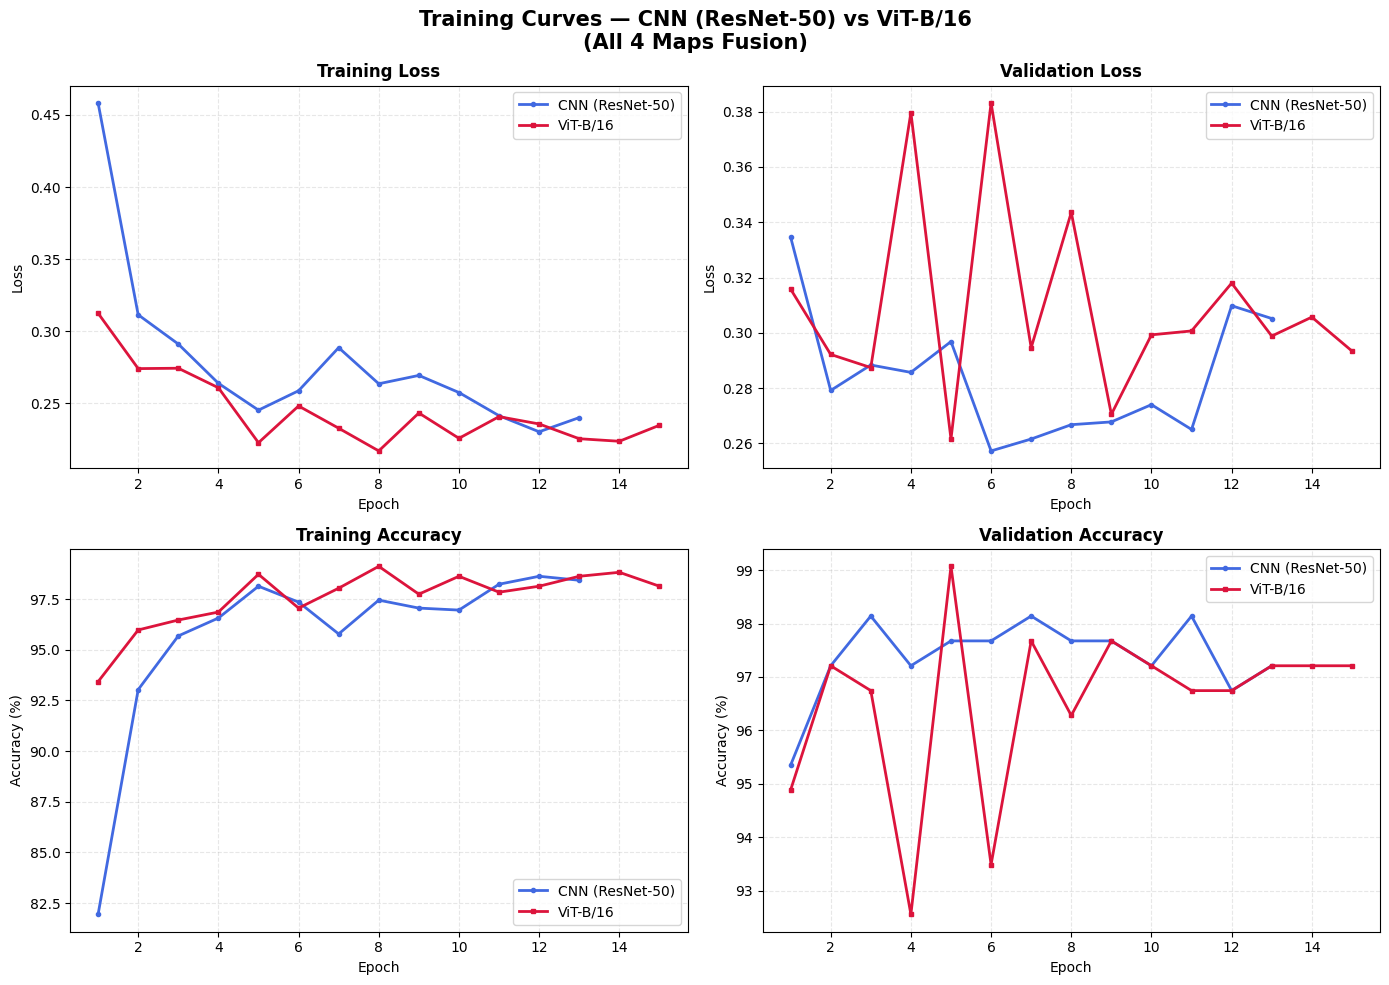

Figure saved: /content/training_curves.png


In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    'Training Curves — CNN (ResNet-50) vs ViT-B/16\n(All 4 Maps Fusion)',
    fontsize=15, fontweight='bold'
)

plot_configs = [
    ('train_loss', 'Training Loss',      'Loss',         axes[0, 0]),
    ('val_loss',   'Validation Loss',    'Loss',         axes[0, 1]),
    ('train_acc',  'Training Accuracy',  'Accuracy (%)', axes[1, 0]),
    ('val_acc',    'Validation Accuracy','Accuracy (%)', axes[1, 1]),
]

for key, title, ylabel, ax in plot_configs:
    scale = 100 if 'acc' in key else 1
    cnn_vals = [v * scale for v in cnn_history[key]]
    vit_vals = [v * scale for v in vit_history[key]]

    ax.plot(
        range(1, len(cnn_vals) + 1), cnn_vals,
        color='royalblue', linewidth=2, marker='o', markersize=3,
        label='CNN (ResNet-50)'
    )
    ax.plot(
        range(1, len(vit_vals) + 1), vit_vals,
        color='crimson', linewidth=2, marker='s', markersize=3,
        label='ViT-B/16'
    )
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: /content/training_curves.png')

---
## Section 18 — Test Set Evaluation

**Why this step?**  
The test set contains patients that were **never seen** during training or validation. Evaluating on it gives an unbiased estimate of how the model will perform in the real world.

**Metrics explained:**
- **Precision**: of all eyes predicted as Keratoconus, what fraction actually has it? (Low → many false alarms)
- **Recall (Sensitivity)**: of all actual Keratoconus eyes, what fraction did we catch? (Low → missing patients)
- **F1-Score**: harmonic mean of Precision and Recall — useful when classes are imbalanced
- **Support**: number of test samples in each class

> In clinical screening, **Recall is the most important metric** — missing a Keratoconus case (false negative) is more harmful than a false alarm (false positive).

In [23]:
# Use a simple unweighted criterion for evaluation (we want raw performance)
eval_criterion = nn.CrossEntropyLoss()

# Evaluate both models on the held-out test set
_, _, cnn_preds, cnn_labels, cnn_probs = evaluate(cnn_model, test_loader, eval_criterion)
_, _, vit_preds, vit_labels, vit_probs = evaluate(vit_model, test_loader, eval_criterion)

print('=' * 55)
print(' CNN (ResNet-50) — All 4 Maps — Test Set Report')
print('=' * 55)
print(classification_report(
    cnn_labels, cnn_preds,
    target_names=['Normal', 'Keratoconus'],
    digits=4
))

print('=' * 55)
print(' ViT-B/16 — All 4 Maps — Test Set Report')
print('=' * 55)
print(classification_report(
    vit_labels, vit_preds,
    target_names=['Normal', 'Keratoconus'],
    digits=4
))

 CNN (ResNet-50) — All 4 Maps — Test Set Report
              precision    recall  f1-score   support

      Normal     0.9847    0.9556    0.9699       135
 Keratoconus     0.9310    0.9759    0.9529        83

    accuracy                         0.9633       218
   macro avg     0.9579    0.9657    0.9614       218
weighted avg     0.9643    0.9633    0.9635       218

 ViT-B/16 — All 4 Maps — Test Set Report
              precision    recall  f1-score   support

      Normal     0.9851    0.9778    0.9814       135
 Keratoconus     0.9643    0.9759    0.9701        83

    accuracy                         0.9771       218
   macro avg     0.9747    0.9768    0.9757       218
weighted avg     0.9772    0.9771    0.9771       218



---
## Section 19 — Confusion Matrices

**Why this step?**  
A confusion matrix breaks down model predictions into four categories:

|  | Predicted Normal | Predicted Keratoconus |
|--|--|--|
| **Actual Normal** | True Negative (TN) ✅ | False Positive (FP) ❌ |
| **Actual Keratoconus** | False Negative (FN) ❌ | True Positive (TP) ✅ |

In clinical terms:
- **False Negative** (missed Keratoconus): the most dangerous error — a patient who needs treatment is not diagnosed
- **False Positive** (false alarm): inconvenient but less harmful — leads to unnecessary follow-up

Each cell shows both the raw count and the row-percentage (rate per true class), making it easy to read recall for each class directly from the matrix.

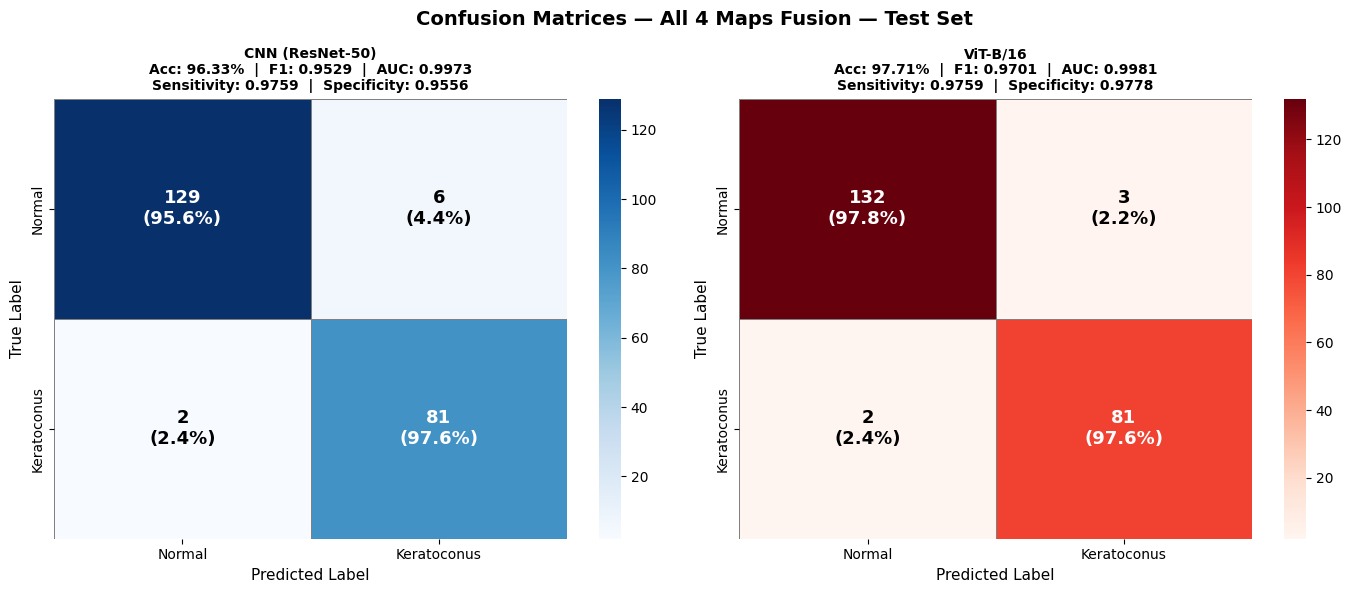

Figure saved: /content/confusion_matrices.png


In [24]:
def plot_confusion_matrix(labels, preds, probs, model_name, ax, cmap):
    """
    Plot a confusion matrix with count and row-percentage annotations.

    Parameters
    ----------
    labels     : ground truth labels
    preds      : predicted labels
    probs      : predicted probabilities for class 1 (used for AUC in title)
    model_name : string for the subplot title
    ax         : matplotlib Axes object
    cmap       : color map string
    """
    cm      = confusion_matrix(labels, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # Row-normalize

    # Draw heatmap without auto annotations
    sns.heatmap(
        cm, annot=False, cmap=cmap, ax=ax,
        xticklabels=['Normal', 'Keratoconus'],
        yticklabels=['Normal', 'Keratoconus'],
        linewidths=0.5, linecolor='gray'
    )

    # Manually add count + percentage text in each cell
    for i in range(2):
        for j in range(2):
            text_color = 'white' if cm_norm[i, j] > 0.5 else 'black'
            ax.text(
                j + 0.5, i + 0.5,
                f'{cm[i, j]}\n({cm_norm[i, j]*100:.1f}%)',
                ha='center', va='center',
                fontsize=13, fontweight='bold', color=text_color
            )

    # Compute summary metrics for the title
    acc  = accuracy_score(labels, preds)
    f1   = f1_score(labels, preds, pos_label=1)
    auc  = roc_auc_score(labels, probs)
    sens = recall_score(labels, preds, pos_label=1)   # Sensitivity (Recall for KC)
    spec = recall_score(labels, preds, pos_label=0)   # Specificity (Recall for Normal)

    ax.set_title(
        f'{model_name}\n'
        f'Acc: {acc*100:.2f}%  |  F1: {f1:.4f}  |  AUC: {auc:.4f}\n'
        f'Sensitivity: {sens:.4f}  |  Specificity: {spec:.4f}',
        fontweight='bold', fontsize=10
    )
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    'Confusion Matrices — All 4 Maps Fusion — Test Set',
    fontsize=14, fontweight='bold'
)

plot_confusion_matrix(cnn_labels, cnn_preds, cnn_probs, 'CNN (ResNet-50)', axes[0], 'Blues')
plot_confusion_matrix(vit_labels, vit_preds, vit_probs, 'ViT-B/16',        axes[1], 'Reds')

plt.tight_layout()
plt.savefig('/content/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: /content/confusion_matrices.png')

---
## Section 20 — ROC Curves

**Why this step?**  
The ROC (Receiver Operating Characteristic) curve plots **True Positive Rate (Sensitivity)** against **False Positive Rate (1 - Specificity)** at every possible classification threshold.

**Why use a continuous threshold instead of 0.5?**  
By adjusting the classification threshold, a clinician can trade off between sensitivity and specificity. For example, a low threshold catches more Keratoconus cases (higher recall) at the cost of more false alarms.

**AUC (Area Under the Curve):**
- `AUC = 1.0` — perfect classifier
- `AUC = 0.5` — random guessing
- `AUC > 0.95` — excellent for clinical screening

The AUC is **threshold-independent** and measures the model's overall discriminative power.

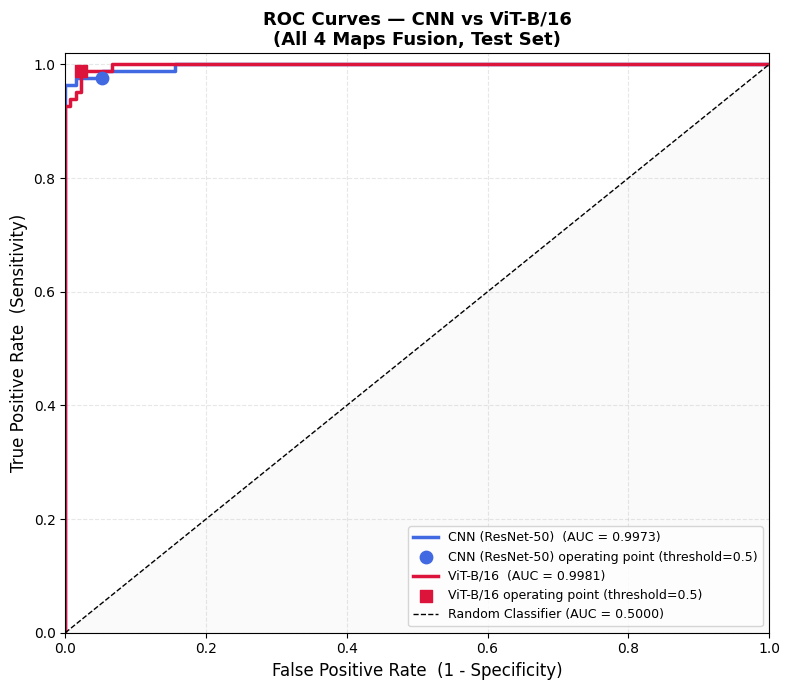

Figure saved: /content/roc_curves.png


In [25]:
fig, ax = plt.subplots(figsize=(8, 7))

for probs, labels, name, color, marker in [
    (cnn_probs, cnn_labels, 'CNN (ResNet-50)', 'royalblue', 'o'),
    (vit_probs, vit_labels, 'ViT-B/16',        'crimson',   's'),
]:
    fpr, tpr, thresholds = roc_curve(labels, probs)
    auc_score = roc_auc_score(labels, probs)

    ax.plot(
        fpr, tpr, color=color, linewidth=2.5,
        label=f'{name}  (AUC = {auc_score:.4f})'
    )
    # Mark the operating point at threshold=0.5
    op_idx = np.argmin(np.abs(thresholds - 0.5))
    ax.scatter(
        fpr[op_idx], tpr[op_idx],
        color=color, s=80, marker=marker, zorder=5,
        label=f'{name} operating point (threshold=0.5)'
    )

# Random classifier baseline
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.5000)')
ax.fill_between([0, 1], [0, 1], alpha=0.04, color='gray')

ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate  (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate  (Sensitivity)', fontsize=12)
ax.set_title(
    'ROC Curves — CNN vs ViT-B/16\n(All 4 Maps Fusion, Test Set)',
    fontsize=13, fontweight='bold'
)
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('/content/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: /content/roc_curves.png')

---
## Section 21 — Final Model Comparison

**Why this step?**  
We produce three complementary views of the comparison:

1. **Numerical summary table** — precise values for all metrics
2. **Side-by-side bar chart** — easy visual comparison of each metric
3. **Radar chart (spider chart)** — overall performance profile showing which model excels across all dimensions simultaneously

**Metrics reported:**
- **Accuracy** — overall correct predictions
- **Precision** — positive predictive value (how reliable are Keratoconus predictions)
- **Recall (Sensitivity)** — true positive rate (how many KC cases we catch)
- **F1-Score** — balanced precision-recall measure
- **Specificity** — true negative rate (how well we avoid false alarms in normal eyes)
- **AUC-ROC** — overall discriminative power at all thresholds

In [26]:
def compute_all_metrics(labels, preds, probs) -> dict:
    """Compute a full set of binary classification metrics."""
    return {
        'Accuracy (%)'  : accuracy_score(labels, preds) * 100,
        'Precision'     : precision_score(labels, preds, pos_label=1),
        'Recall'        : recall_score(labels, preds,    pos_label=1),
        'F1-Score'      : f1_score(labels, preds,         pos_label=1),
        'Specificity'   : recall_score(labels, preds,    pos_label=0),
        'AUC-ROC'       : roc_auc_score(labels, probs),
    }

cnn_metrics = compute_all_metrics(cnn_labels, cnn_preds, cnn_probs)
vit_metrics = compute_all_metrics(vit_labels, vit_preds, vit_probs)

# ── Numerical Summary Table ───────────────────────────────────────────────────
comparison_df = pd.DataFrame({
    'CNN (ResNet-50)' : cnn_metrics,
    'ViT-B/16'        : vit_metrics
})
# Add a 'Winner' column
comparison_df['Winner'] = comparison_df.apply(
    lambda row: 'CNN' if row['CNN (ResNet-50)'] > row['ViT-B/16'] else 'ViT', axis=1
)

print('\n' + '=' * 62)
print('  📊 Final Test Set Metrics — All 4 Maps Fusion')
print('=' * 62)
print(comparison_df.round(4).to_string())
print('=' * 62)


  📊 Final Test Set Metrics — All 4 Maps Fusion
              CNN (ResNet-50)  ViT-B/16 Winner
Accuracy (%)          96.3303   97.7064    ViT
Precision              0.9310    0.9643    ViT
Recall                 0.9759    0.9759    ViT
F1-Score               0.9529    0.9701    ViT
Specificity            0.9556    0.9778    ViT
AUC-ROC                0.9973    0.9981    ViT


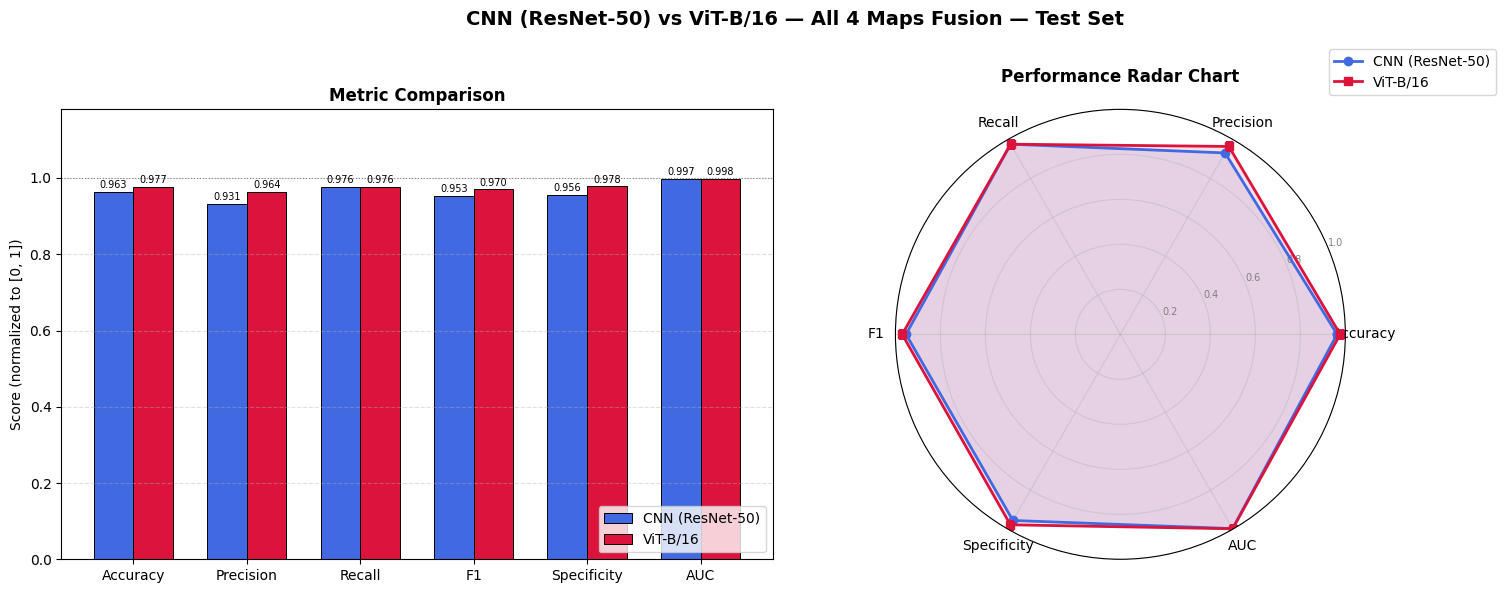

Figure saved: /content/model_comparison.png


In [27]:
# ── Side-by-Side Bar Chart + Radar Chart ─────────────────────────────────────
metric_keys   = list(cnn_metrics.keys())
radar_labels  = ['Accuracy', 'Precision', 'Recall', 'F1', 'Specificity', 'AUC']

# Normalize Accuracy to [0,1] for the radar chart (same scale as other metrics)
cnn_vals = [cnn_metrics[k] / 100 if k == 'Accuracy (%)' else cnn_metrics[k] for k in metric_keys]
vit_vals = [vit_metrics[k] / 100 if k == 'Accuracy (%)' else vit_metrics[k] for k in metric_keys]

fig = plt.figure(figsize=(16, 6))
fig.suptitle(
    'CNN (ResNet-50) vs ViT-B/16 — All 4 Maps Fusion — Test Set',
    fontsize=14, fontweight='bold'
)

# ── Left: Bar Chart ────────────────────────────────────────────────────────
ax_bar = fig.add_subplot(1, 2, 1)
x      = np.arange(len(radar_labels))
width  = 0.35

bars_cnn = ax_bar.bar(x - width/2, cnn_vals, width, label='CNN (ResNet-50)',
                       color='royalblue', edgecolor='black', linewidth=0.7)
bars_vit = ax_bar.bar(x + width/2, vit_vals, width, label='ViT-B/16',
                       color='crimson', edgecolor='black', linewidth=0.7)

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(radar_labels, fontsize=10)
ax_bar.set_ylim([0, 1.18])
ax_bar.set_ylabel('Score (normalized to [0, 1])')
ax_bar.set_title('Metric Comparison', fontweight='bold')
ax_bar.legend(loc='lower right')
ax_bar.grid(axis='y', alpha=0.4, linestyle='--')
ax_bar.axhline(y=1.0, color='gray', linestyle=':', linewidth=0.8)

# Add value labels on top of each bar
for c_val, v_val, xi in zip(cnn_vals, vit_vals, x):
    ax_bar.text(xi - width/2, c_val + 0.01, f'{c_val:.3f}', ha='center', fontsize=7)
    ax_bar.text(xi + width/2, v_val + 0.01, f'{v_val:.3f}', ha='center', fontsize=7)

# ── Right: Radar Chart ─────────────────────────────────────────────────────
N      = len(radar_labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles_closed = angles + [angles[0]]   # Close the polygon

ax_radar = fig.add_subplot(1, 2, 2, polar=True)

for vals, color, name, marker in [
    (cnn_vals, 'royalblue', 'CNN (ResNet-50)', 'o'),
    (vit_vals, 'crimson',   'ViT-B/16',        's'),
]:
    closed_vals = vals + [vals[0]]
    ax_radar.plot(angles_closed, closed_vals, marker + '-', linewidth=2,
                  color=color, label=name, markersize=6)
    ax_radar.fill(angles_closed, closed_vals, alpha=0.12, color=color)

ax_radar.set_xticks(angles)
ax_radar.set_xticklabels(radar_labels, fontsize=10)
ax_radar.set_ylim(0, 1)
ax_radar.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax_radar.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=7, color='gray')
ax_radar.set_title('Performance Radar Chart', fontweight='bold', pad=20)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15))
ax_radar.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('/content/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: /content/model_comparison.png')

In [28]:
# ── Copy All Figures to Google Drive ─────────────────────────────────────────
DRIVE_RESULTS = DRIVE_ROOT / 'results'
DRIVE_RESULTS.mkdir(exist_ok=True)

for png_file in Path('/content').glob('*.png'):
    destination = DRIVE_RESULTS / png_file.name
    shutil.copy2(png_file, destination)
    print(f'✅ {png_file.name} → Drive/ORBSCAN_Dataset/results/')

print(f'\n🎉 All done! Results saved to: {DRIVE_RESULTS}')

✅ all_maps_sample.png → Drive/ORBSCAN_Dataset/results/
✅ augmentation_demo.png → Drive/ORBSCAN_Dataset/results/
✅ confusion_matrices.png → Drive/ORBSCAN_Dataset/results/
✅ model_comparison.png → Drive/ORBSCAN_Dataset/results/
✅ training_curves.png → Drive/ORBSCAN_Dataset/results/
✅ data_split.png → Drive/ORBSCAN_Dataset/results/
✅ dataset_overview.png → Drive/ORBSCAN_Dataset/results/
✅ roc_curves.png → Drive/ORBSCAN_Dataset/results/

🎉 All done! Results saved to: /content/drive/MyDrive/ORBSCAN_Dataset/results


---
## 📋 Summary

### Architecture Overview

| Component | CNN (ResNet-50) | ViT-B/16 |
|-----------|----------------|----------|
| Input | `[B, 12, 224, 224]` | `[B, 12, 224, 224]` |
| Modified layer | Conv2d stem (3→12) | Patch embed proj (3→12) |
| Frozen layers | Layer1, Layer2 | Transformer blocks 0–7 |
| Trainable | Layer3, Layer4, Head | Blocks 8–11, Patch embed, Head |
| Output | `[B, 2]` logits | `[B, 2]` logits |

### Map-to-Channel Mapping
```
Channels  0–2  →  Axial Curvature      (R, G, B)
Channels  3–5  →  Anterior Elevation   (R, G, B)
Channels  6–8  →  Posterior Elevation  (R, G, B)
Channels  9–11 →  Pachymetry           (R, G, B)
```

### Output Files in Google Drive
| Path | File | Description |
|------|------|-------------|
| `weights/` | `MultiMap_CNN_ResNet50_best.pth` | Best CNN checkpoint |
| `weights/` | `MultiMap_ViT_B16_best.pth` | Best ViT checkpoint |
| `results/` | `dataset_overview.png` | EDA charts |
| `results/` | `all_maps_sample.png` | 4-map visual comparison |
| `results/` | `augmentation_demo.png` | Augmentation preview |
| `results/` | `data_split.png` | Split class balance |
| `results/` | `training_curves.png` | Loss & accuracy curves |
| `results/` | `confusion_matrices.png` | CM with counts & percentages |
| `results/` | `roc_curves.png` | ROC comparison |
| `results/` | `model_comparison.png` | Bar + radar chart |

---
*Reference: Lazouni et al. "CornOrb: A Multimodal Dataset of Orbscan Corneal Topography and Clinical Annotations for Keratoconus Detection." arXiv:2603.21245 (2026).*